# **Exploratory Data Analysis on Online Course Enrollment Data**


## Prepare and setup the lab environment


In [1]:
!pip install seaborn
!pip install wordcloud
!pip install pandas
!pip install matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

%matplotlib inline

In [3]:
# also set a random state
rs = 123

### Load and explore the dataset

In [4]:
# Point to the datasets stored on the cloud
course_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv"
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"

In [5]:
course_df = pd.read_csv(course_genre_url)
ratings_df = pd.read_csv(ratings_url)

In [6]:
course_df.columns

Index(['COURSE_ID', 'TITLE', 'Database', 'Python', 'CloudComputing',
       'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision',
       'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev',
       'Blockchain'],
      dtype='object')

In [7]:
course_df.shape[0]

307

In [8]:
course_df.dtypes

,0
COURSE_ID,object
TITLE,object
Database,int64
Python,int64
CloudComputing,int64
DataAnalysis,int64
Containers,int64
MachineLearning,int64
ComputerVision,int64
DataScience,int64


In [9]:
course_df.iloc[1, ]

,1
COURSE_ID,ML0122EN
TITLE,accelerating deep learning with gpu
Database,0
Python,1
CloudComputing,0
DataAnalysis,0
Containers,0
MachineLearning,1
ComputerVision,0
DataScience,1


**Plot a Word Cloud from Course Titles**


In [10]:
titles = " ".join(title for title in course_df['TITLE'].astype(str))

In [11]:
titles

'robots are coming  build iot apps with watson  swift  and node red accelerating deep learning with gpu consuming restful services using the reactive jax rs client analyzing big data in r using apache spark containerizing  packaging  and running a spring boot application cloud native security conference  data security data science bootcamp with r for university proffesors learn how to use docker containers for iterative development scorm test course create your first mongodb database testing microservices with the arquillian managed container cloud pak for integration essentials watson analytics for social media data science bootcamp with python for university professors  advance create a cryptocurrency trading algorithm in python data   ai essentials securing java microservices with eclipse microprofile json web token  microprofile jwt  enabling distributed tracing in microservices with zipkin sql access for hadoop ybrid cloud conference  ai pipelines lab dataops methodology data   ai

In [12]:
# English Stopwords
stopwords = set(STOPWORDS)
stopwords.update(["getting started", "using", "enabling", "template", "university", "end", "introduction", "basic"])

In [14]:
wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400)

In [15]:
wordcloud.generate(titles)

In [16]:
# Disable axis display
plt.axis("off")
# Create a new figure with a specified size
plt.figure(figsize=(40,20))
# Adjust the layout to ensure tight spacing
plt.tight_layout(pad=0)
# Display the word cloud image with bilinear interpolation
plt.imshow(wordcloud, interpolation='bilinear')
# Show the plot
plt.show()

Output hidden; open in https://colab.research.google.com to view.

**_TASK: Analyze Course Genres_**

In [17]:
course_df[course_df["MachineLearning"] == 1]

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
15,DAI101EN,data ai essentials,0,0,0,0,0,1,0,0,0,0,0,0,0,0
19,HCC105EN,ybrid cloud conference ai pipelines lab,0,0,0,0,0,1,0,0,0,0,0,0,0,0
21,DS0132EN,data ai jumpstart your journey,0,0,0,0,0,1,0,0,0,0,0,0,0,0
24,BENTEST4,ai for everyone master the basics,0,0,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,excourse61,convolutional neural networks in tensorflow,0,0,0,0,0,1,1,0,0,0,0,0,0,0
282,excourse69,machine learning with big data,0,0,0,0,0,1,0,0,1,0,0,0,0,0
290,excourse77,natural language processing with attention models,0,0,0,0,0,1,0,0,0,0,0,0,0,0
291,excourse78,natural language processing with sequence models,0,0,0,0,0,1,0,0,0,0,0,0,0,0


**_TODO: Find all courses with genres `MachineLearning` == 1 and `BigData` == 1_**

In [18]:
course_df[
    (course_df["MachineLearning"] == 1) &
    (course_df["BigData"] == 1)
]

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
46,GPXX0BUBEN,insurance risk assessment with montecarlo meth...,0,0,0,0,0,1,0,0,1,0,0,0,0,0
59,TA0106EN,text analytics at scale,0,0,0,0,0,1,0,1,1,0,0,0,0,0
184,BD0221EN,spark mllib,0,0,0,0,0,1,0,0,1,0,0,0,0,0
282,excourse69,machine learning with big data,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [19]:
genres = course_df.columns[2:]
genres

Index(['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers',
       'MachineLearning', 'ComputerVision', 'DataScience', 'BigData',
       'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain'],
      dtype='object')

**_TODO: Use the Pandas dataframe sum() and sort_values() methods to genreate a sorted course count per genre. You may also implement the task with different solutions_**

In [20]:
genre_counts = course_df[genres].sum().sort_values(ascending=False)

genre_counts

,0
BackendDev,78
MachineLearning,69
Database,60
DataAnalysis,56
DataScience,38
CloudComputing,37
BigData,36
Python,28
FrontendDev,19
Containers,17


**_TODO: Use seaborn barplot or other plot methods to plot course genre counts using a barchart. The x-axis is the course genre and the y-axis is the course count per genre_**


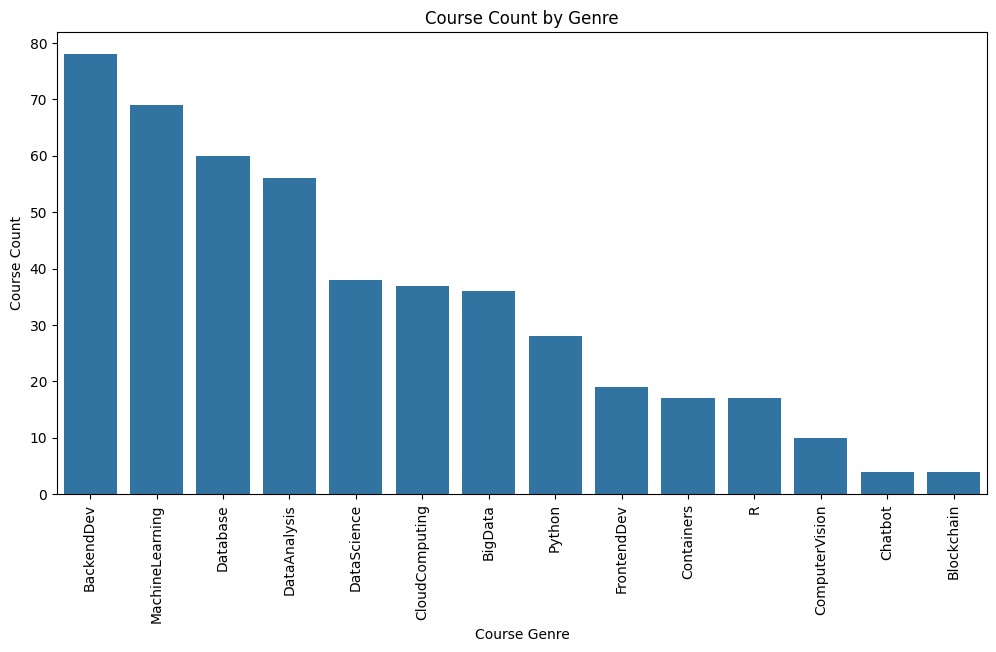

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values
)

plt.xticks(rotation=90)
plt.xlabel("Course Genre")
plt.ylabel("Course Count")
plt.title("Course Count by Genre")

plt.show()

## **TASK: Analyze Course Enrollments**

In [23]:
ratings_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


In [24]:
ratings_df['rating'].unique()

array([5, 3, 4])

In [25]:
ratings_df.shape[0]

233306

_TODO: Apply Pandas' groupby() and size() method on the user column to aggregate the rating count for each user, then report the total number of users after aggregation._


In [26]:
user_ratings = ratings_df.groupby("user").size().reset_index(name="rating_count")

print("Total number of users:", len(user_ratings))

user_ratings

Total number of users: 33901


,user,rating_count
0,2,61
1,4,44
2,5,59
3,7,1
4,8,3
...,...,...
33896,2102054,8
33897,2102356,1
33898,2102680,11
33899,2102983,1


_TODO: Use describe() to report the statistics summary of the user enrollments._


In [27]:
user_ratings["rating_count"].describe()

,rating_count
count,33901.000000
mean,6.881980
std,5.823548
min,1.000000
25%,2.000000
50%,6.000000
75%,9.000000
max,61.000000


_TODO: Plot the histogram of user rating counts_

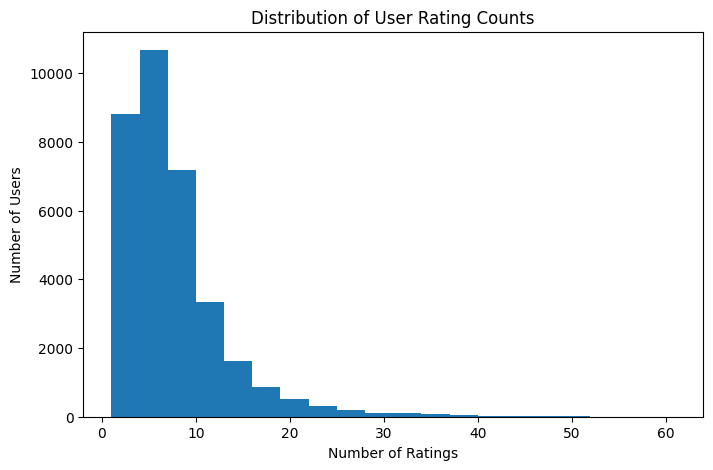

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(user_ratings["rating_count"], bins=20)

plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.title("Distribution of User Rating Counts")

plt.show()

## **Task: Find the Top-20 Most Popular Courses**

_TODO: Use Pandas groupby() and size() methods on the item column to aggregate the rating count for each item, then use the sort_values() method to sort the course enrollment count, and use the slice method to get the top 20 courses. You may also implement this task with different solutions_


In [30]:
top_20 = (
    ratings_df.groupby("item")
    .size()
    .reset_index(name="enrollments")
    .sort_values(by="enrollments", ascending=False)
    .head(20)
)

top_20

,item,enrollments
101,PY0101EN,14936
54,DS0101EN,14477
4,BD0101EN,13291
5,BD0111EN,10599
42,DA0101EN,8303
55,DS0103EN,7719
82,ML0101ENv3,7644
18,BD0211EN,7551
56,DS0105EN,7199
1,BC0101EN,6719


_TODO: Use Pandas merge() method to join the course_df (contains the course title column)._


In [31]:
top_20_courses = pd.merge(
    top_20,
    course_df[["COURSE_ID", "TITLE"]],
    left_on="item",
    right_on="COURSE_ID",
    how="left"
)

top_20_courses

,item,enrollments,COURSE_ID,TITLE
0,PY0101EN,14936,PY0101EN,python for data science
1,DS0101EN,14477,DS0101EN,introduction to data science
2,BD0101EN,13291,BD0101EN,big data 101
3,BD0111EN,10599,BD0111EN,hadoop 101
4,DA0101EN,8303,DA0101EN,data analysis with python
5,DS0103EN,7719,DS0103EN,data science methodology
6,ML0101ENv3,7644,ML0101ENv3,machine learning with python
7,BD0211EN,7551,BD0211EN,spark fundamentals i
8,DS0105EN,7199,DS0105EN,data science hands on with open source tools
9,BC0101EN,6719,BC0101EN,blockchain essentials


In [32]:
# Get the total course enrollments again
total = ratings_df.shape[0]
total

233306

In [33]:
top = 0

In [34]:
top = top_20["enrollments"].sum()

top

np.int64(147688)

In [35]:
print(f"Percentage of the top course enrollments {round((top * 100)/total, 2)}%")

Percentage of the top course enrollments 63.3%
